# 05_统计检验方法-方差分析

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文分享的是统计检验方法中的方差分析\~

方差分析是一种统计方法，用于比较**多个样本组的均值是否显著不同**。它不是直接比较均值，而是通过比较组间和组内的“变异”（方差）来判断：

- **组内方差**：每组内部数据的波动程度，反映组内部个体间的差异。
- **组间方差**：不同组均值之间的差异程度，反映组间的差异。

**假设**：

- **原假设** $H_0$：各组均值相等（无显著差异）。
- **备择假设** $H_1$：至少有一组均值与其他组不同。

### 简单例子

**情境：咖啡店营销策略的例子**

你希望评估三种营销策略（折扣、赠品、免费试喝）对每日销量的影响。你分别记录了每种策略下的每日销量数据，最终发现三组数据的均值不同。

接下来，方差分析会回答：

- **问题 1**：这些差异是由于营销策略的不同，还是随机误差导致的？
- **问题 2**：哪种策略效果最佳？

## 1. 方差分析的本质

1. 将总变异分为两部分：  
$总变异 = 组间变异 + 组内变异$  
如果组间变异显著大于组内变异，说明不同组均值确实存在差异。
2. 通过**F检验**量化组间变异与组内变异的比值。

### 特点

**1. 应用场景：**

- 比较多个组的均值是否显著不同。
- 用于实验设计分析，比如农业实验中比较肥料效果，医学实验中比较治疗方法。

**2. 假设条件：**

- 数据满足正态分布。
- 各组方差相等（方差齐性）。
- 样本独立。

**3. 适用范围：**

- 单因素方差分析（One-way ANOVA）：单一因素的不同水平对结果的影响。
- 双因素或多因素方差分析：考虑多个因素的交互作用。

## 2. 图形展示

数据的分布特征对于理解方差分析非常重要。以下图表能帮助直观理解方差分析的原理和结果。

**箱线图**：

箱线图清晰显示各组的分布范围、中位数和潜在异常值。例如，三种营销策略的销量数据可能呈现如下分布：

- 组内数据紧密分布，组间均值差异显著（说明营销策略有效）。
- 组间差异不明显，可能无法拒绝均值相等的假设。

**均值-标准误图**：

此图展示每组的均值及其误差范围（通常为95%置信区间），可直观比较组间差异。

**总方差分解可视化**：

通过分段柱状图展示总方差是如何分解为组间方差和组内方差，帮助理解方差分析的核心思想。

## 3. 公式推导

在方差分析中，核心公式涉及总平方和、组间平方和和组内平方和，以及它们之间的关系。

### 定义与公式

**1. 总平方和 (SST, Total Sum of Squares)**：


$$
SST = \sum_{i=1}^k \sum_{j=1}^{n_i} (x_{ij} - \bar{x})^2
$$


- $\bar{x}$：所有样本的总体均值。

**2. 组间平方和 (SSB, Sum of Squares Between Groups)**：


$$
SSB = \sum_{i=1}^k n_i (\bar{x}_i - \bar{x})^2
$$


- $\bar{x}_i$：第$i$组的均值，$n_i$：第$i$组样本数。

**3. 组内平方和 (SSE, Sum of Squares Within Groups)**：


$$
SSE = \sum_{i=1}^k \sum_{j=1}^{n_i} (x_{ij} - \bar{x}_i)^2
$$


- 表示组内每个数据点与其组均值之间的差异。

**4. 均方 (Mean Squares)**：

- **组间均方 (MSB)**:  
$MSB = \frac{SSB}{k-1}$

$k-1$：组间自由度。

- **组内均方 (MSE)**:  
$MSE = \frac{SSE}{N-k}$

$N-k$：组内自由度。

**5. F统计量：**  
$F = \frac{MSB}{MSE}$

- 若F值显著大于1，说明组间差异较大。

### 公式之间的关系

总平方和由组间平方和和组内平方和组成：$SST = SSB + SSE$

## 4. 代码实现

### 生成模拟数据

以下代码模拟三个组的销量数据，分别假设均值和标准差不同。

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

# 模拟数据
np.random.seed(42)
group_a = np.random.normal(loc=50, scale=5, size=30)
group_b = np.random.normal(loc=55, scale=5, size=30)
group_c = np.random.normal(loc=60, scale=5, size=30)

# 数据整理
data = pd.DataFrame({
    'value': np.concatenate([group_a, group_b, group_c]),
    'group': ['A'] * 30 + ['B'] * 30 + ['C'] * 30
})

### 数据可视化

#### 1) **箱线图**

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_9759/2572917268.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y='value', data=data, palette='Set2')


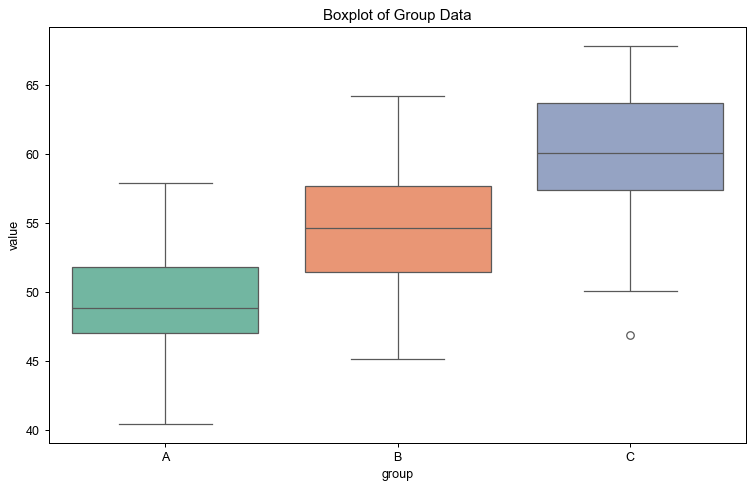

In [3]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='group', y='value', data=data, palette='Set2')
plt.title('Boxplot of Group Data')
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_004.png)

#### 2) **均值-标准误图**

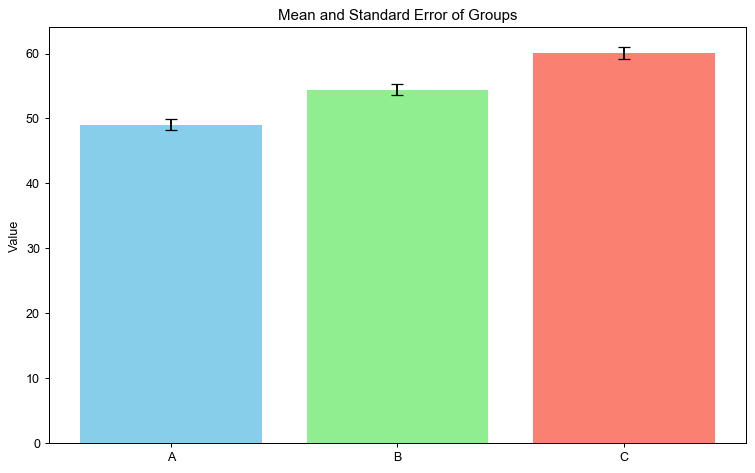

In [4]:
group_means = data.groupby('group')['value'].mean()
group_sems = data.groupby('group')['value'].sem()

plt.figure(figsize=(10, 6))
plt.bar(group_means.index, group_means, yerr=group_sems, capsize=5, color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Mean and Standard Error of Groups')
plt.ylabel('Value')
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_005.png)

### 方差分析计算

In [5]:
# 方差分析
f_stat, p_value = f_oneway(group_a, group_b, group_c)
print(f"F-statistic: {f_stat:.2f}, p-value: {p_value:.4f}")

F-statistic: 40.98, p-value: 0.0000


若p值小于显著性水平（如0.05），则拒绝原假设，认为组均值之间存在显著差异。

### 多因素应用

**情境扩展：** 比较不同地区、不同营销策略的销量影响，可以使用双因素方差分析（Two-way ANOVA）。

在Python中可以用`statsmodels`库实现：

In [6]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 模拟双因素数据
data['region'] = ['North'] * 45 + ['South'] * 45
model = ols('value ~ group + region + group:region', data=data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                    sum_sq    df             F        PR(>F)
group         5.582237e-01   2.0  1.255381e-02  9.875265e-01
region       -1.485619e-13   1.0 -6.681975e-15  1.000000e+00
group:region  1.833865e+03   2.0  4.124153e+01  2.763854e-13
Residual      1.912058e+03  86.0           NaN           NaN


在实际数据分析中，方差分析也用于特征选择和模型解释。例如：

- 将分类变量转换为哑变量后，可以用线性回归分析各变量对结果的影响。
- 方差分析结果可用于过滤无关特征，提升模型性能。